In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Sample - Superstore.csv", encoding='latin1')
print(df.shape)
print(df.head())

Matplotlib is building the font cache; this may take a moment.


(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [2]:
# Check missing values and data info
print(df.isnull().sum())
print("------------------")
print(df.dtypes)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
------------------
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [3]:
# Convert Order Date to proper date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Basic statistics of sales and profit
print(df[['Sales', 'Profit', 'Quantity']].describe())

              Sales       Profit     Quantity
count   9994.000000  9994.000000  9994.000000
mean     229.858001    28.656896     3.789574
std      623.245101   234.260108     2.225110
min        0.444000 -6599.978000     1.000000
25%       17.280000     1.728750     2.000000
50%       54.490000     8.666500     3.000000
75%      209.940000    29.364000     5.000000
max    22638.480000  8399.976000    14.000000


C:\Users\ewanm\AppData\Local\Temp\ipykernel_27464\1790761675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_d')


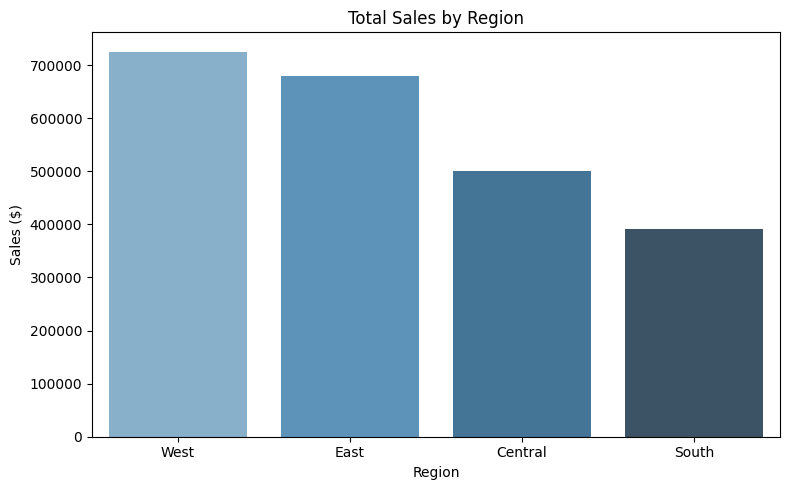

In [4]:
# Chart 1 - Total Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_d')
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("../outputs/sales_by_region.png")
plt.show()

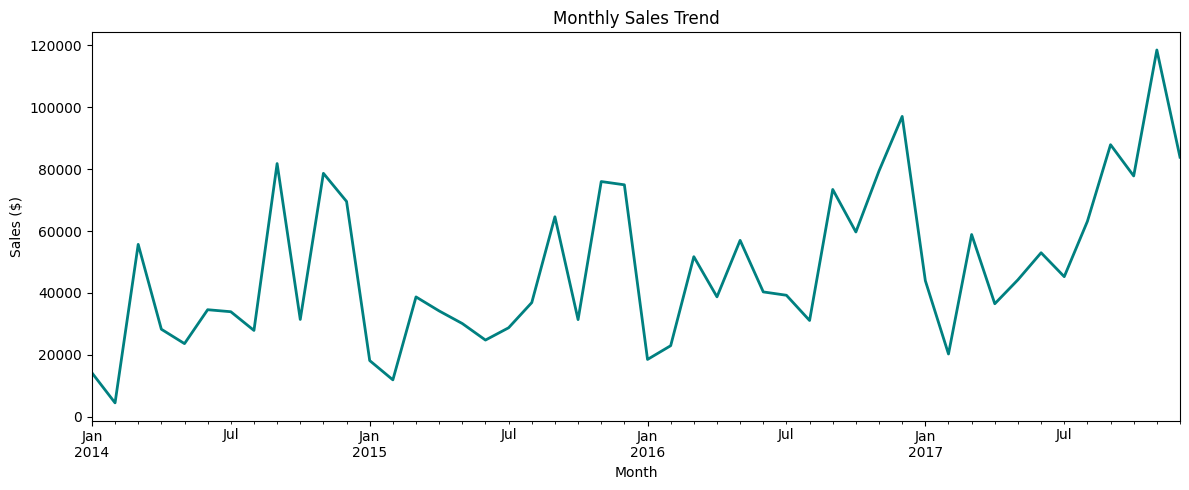

In [5]:
# Chart 2 - Monthly Sales Trend
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', color='teal', linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("../outputs/monthly_trend.png")
plt.show()

C:\Users\ewanm\AppData\Local\Temp\ipykernel_27464\4133217891.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')


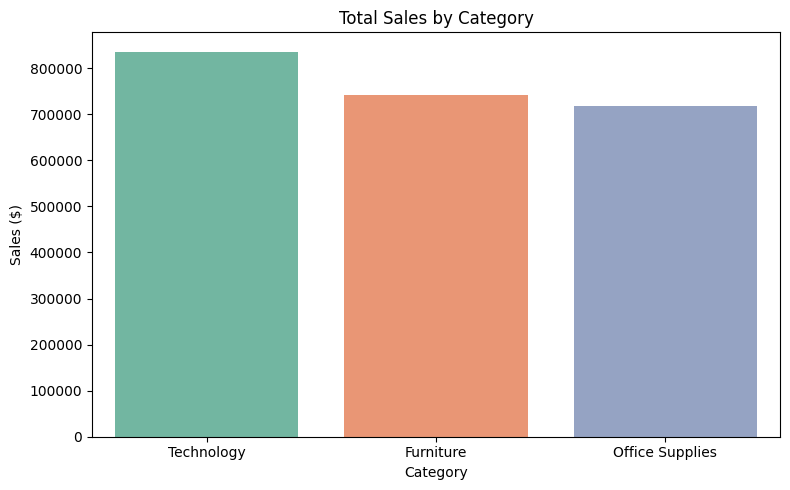

In [6]:
# Chart 3 - Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("../outputs/sales_by_category.png")
plt.show()

C:\Users\ewanm\AppData\Local\Temp\ipykernel_27464\1041123614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette='coolwarm')


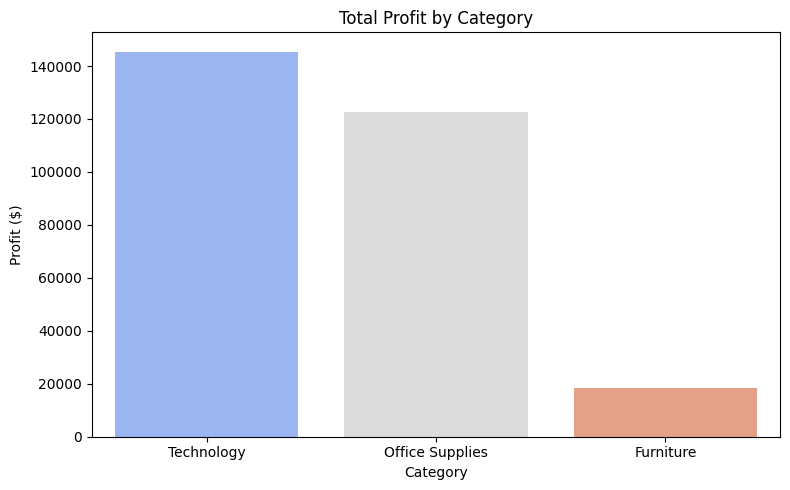

In [7]:
# Chart 4 - Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_profit.index, y=category_profit.values, palette='coolwarm')
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.savefig("../outputs/profit_by_category.png")
plt.show()

In [10]:
# SQL Analysis using SQLite
import sqlite3

# Create clean copy - convert all special columns to string
df_sql = df.copy()
df_sql['Order Date'] = df_sql['Order Date'].astype(str)
df_sql['Ship Date'] = df_sql['Ship Date'].astype(str)
df_sql['Month'] = df_sql['Month'].astype(str)

conn = sqlite3.connect(":memory:")
df_sql.to_sql("sales", conn, index=False, if_exists="replace")

# Top 5 most profitable products
query = """
SELECT "Product Name", 
       ROUND(SUM(Profit), 2) AS Total_Profit
FROM sales 
GROUP BY "Product Name" 
ORDER BY Total_Profit DESC 
LIMIT 5
"""
result = pd.read_sql(query, conn)
print("Top 5 Most Profitable Products:")
print(result)

Top 5 Most Profitable Products:
                                        Product Name  Total_Profit
0              Canon imageCLASS 2200 Advanced Copier      25199.93
1  Fellowes PB500 Electric Punch Plastic Comb Bin...       7753.04
2               Hewlett Packard LaserJet 3310 Copier       6983.88
3                 Canon PC1060 Personal Laser Copier       4570.93
4  HP Designjet T520 Inkjet Large Format Printer ...       4094.98


In [11]:
# Key Business Insights
print("=" * 50)
print("KEY INSIGHTS FROM SALES ANALYSIS")
print("=" * 50)
print("1. West region has highest sales (~$725,000)")
print("2. Technology is most profitable category")
print("3. Sales peak every November-December")
print("4. Furniture has high sales but low profit")
print("5. Canon imageCLASS is most profitable product")
print("=" * 50)

KEY INSIGHTS FROM SALES ANALYSIS
1. West region has highest sales (~$725,000)
2. Technology is most profitable category
3. Sales peak every November-December
4. Furniture has high sales but low profit
5. Canon imageCLASS is most profitable product
